# testing

In [1]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port=5433,
    user="ubuntu",
    dbname="brti"
)
cur = conn.cursor()

# Fetch the latest row by timestamp
cur.execute("SELECT * FROM brti_prices ORDER BY timestamp DESC LIMIT 1;")
row = cur.fetchone()
print(row)

cur.close()
conn.close()

(155885, Decimal('105208.57'), datetime.datetime(2025, 6, 17, 14, 52, 12, 220266, tzinfo=datetime.timezone.utc))


# download all the data and put into a df

In [2]:
import psycopg2
import pandas as pd
from zoneinfo import ZoneInfo

# DB connection parameters
DB_HOST = "localhost"
DB_PORT = 5433
DB_NAME = "brti"
DB_USER = "ubuntu"

# Connect and load data into DataFrame
with psycopg2.connect(
    host=DB_HOST,
    port=DB_PORT,
    dbname=DB_NAME,
    user=DB_USER
) as conn:
    df = pd.read_sql_query("""
        SELECT id, price, timestamp 
        FROM brti_prices 
        ORDER BY timestamp ASC;
    """, conn)

# Convert timestamps to US/Eastern timezone
df['timestamp'] = df['timestamp'].dt.tz_convert(ZoneInfo("US/Eastern"))

# Preview
df.tail()

C:\Users\chris\AppData\Local\Temp\ipykernel_22000\1473371053.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("""


,id,price,timestamp
155512,155883,105216.09,2025-06-17 10:52:09.100951-04:00
155513,155884,105215.13,2025-06-17 10:52:10.544752-04:00
155514,155885,105208.57,2025-06-17 10:52:12.220266-04:00
155515,155886,105198.54,2025-06-17 10:52:14.150896-04:00
155516,155887,105160.43,2025-06-17 10:52:16.381327-04:00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155517 entries, 0 to 155516
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype                     
---  ------     --------------   -----                     
 0   id         155517 non-null  int64                     
 1   price      155517 non-null  float64                   
 2   timestamp  155517 non-null  datetime64[ns, US/Eastern]
dtypes: datetime64[ns, US/Eastern](1), float64(1), int64(1)
memory usage: 3.6 MB


# visualize

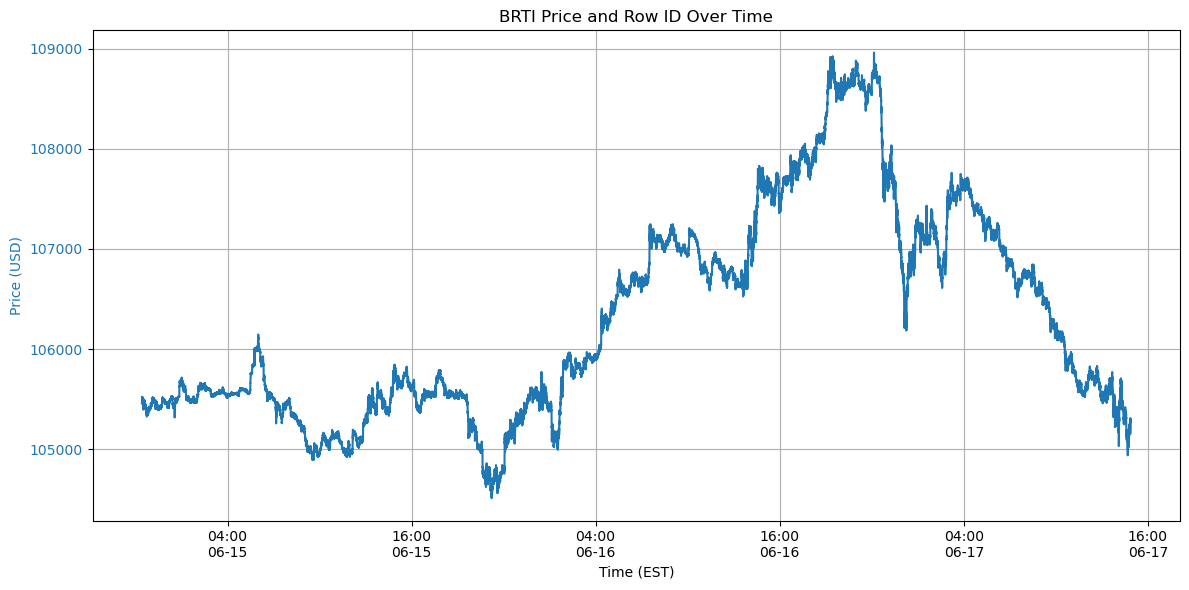

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

timestamps_utc = df['timestamp']
prices = df['price']
ids = df['id']

# Convert timestamps to EST
timestamps_est = [ts.astimezone(ZoneInfo("US/Eastern")) for ts in timestamps_utc]

# === PLOT ===
fig, ax1 = plt.subplots(figsize=(12, 6))

# Price (primary y-axis)
ax1.plot(timestamps_est, prices, label="Price (USD)", color="tab:blue")
ax1.set_xlabel("Time (EST)")
ax1.set_ylabel("Price (USD)", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M\n%m-%d'))

# Title and layout
plt.title("BRTI Price and Row ID Over Time")
fig.tight_layout()
plt.grid(True)
plt.show()

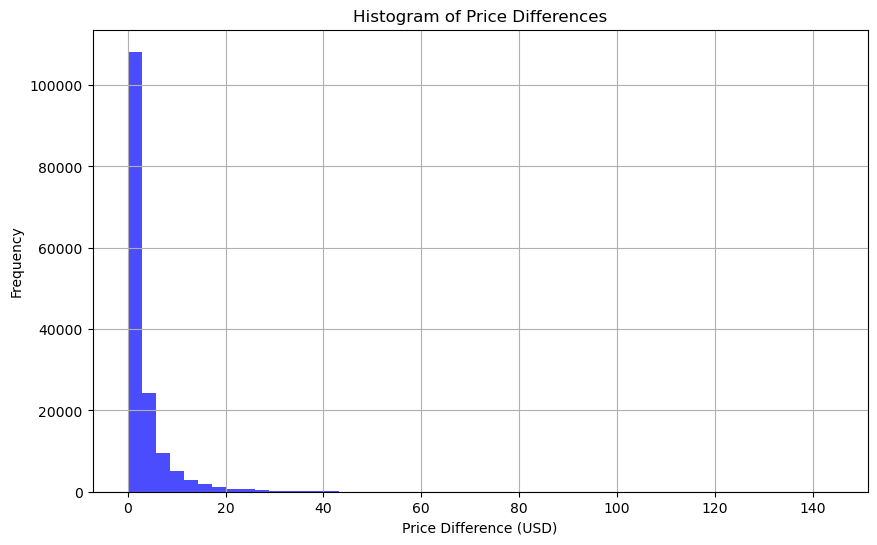

Rows with price differences greater than $0.5:
            id      price                        timestamp  price_diff
20202    20573  105982.83 2025-06-15 01:45:16.062686-04:00       87.71
21714    22085  105698.86 2025-06-15 02:21:15.586767-04:00      113.60
75464    75835  106138.55 2025-06-16 00:21:32.224758-04:00       96.51
82974    83345  106994.63 2025-06-16 03:30:22.710730-04:00       97.91
112202  112573  108488.84 2025-06-16 16:07:06.869292-04:00      107.57
112419  112790  108681.63 2025-06-16 16:12:49.184059-04:00      112.40
118415  118786  107820.43 2025-06-16 18:46:42.066556-04:00      144.02
118730  119101  107701.62 2025-06-16 18:55:24.399557-04:00       82.30
123008  123379  107125.29 2025-06-16 20:50:04.711497-04:00       80.55
136914  137285  106776.69 2025-06-17 02:47:33.994977-04:00      102.47


In [11]:
df['price_diff'] = df['price'].diff().abs()

# plot histogram of price differences
plt.figure(figsize=(10, 6))
plt.hist(df['price_diff'].dropna(), bins=50, color='blue', alpha=0.7)
plt.title("Histogram of Price Differences")
plt.xlabel("Price Difference (USD)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


# check for price differences greater than 0.5
price_threshold = 80
price_diff_above_threshold = df[df['price_diff'] > price_threshold]
# Display rows with significant price differences
print("Rows with price differences greater than $0.5:")
print(price_diff_above_threshold[['id', 'price', 'timestamp', 'price_diff']])